In [3]:
from engine import Value
from nn import *

In [16]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

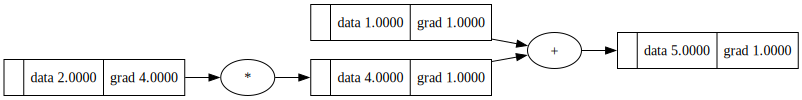

In [4]:
a = Value(1.0)
b = Value(2.0)

c = a + b * b
c.backward()
draw_dot(c)

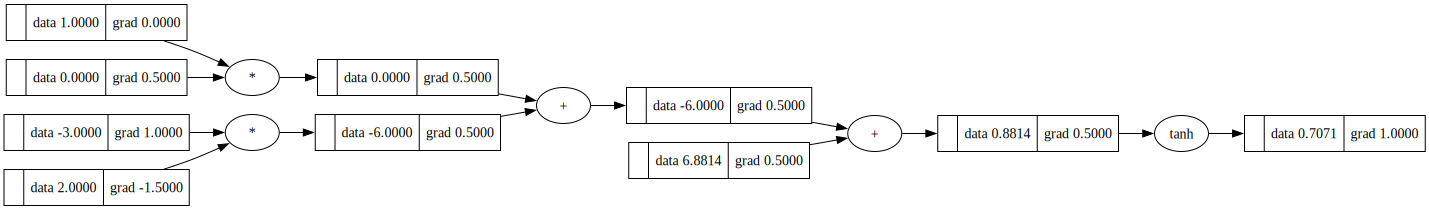

In [6]:
x1 = Value(2.0)
w1 = Value(-3.0)
x2 = Value(0)
w2 = Value(1.0)

b = Value(6.8813735870195432)
n = x1 * w1 + x2 * w2 + b
o = n.tanh()
o.backward()
draw_dot(o)

In [6]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x).data

-0.8507645613137425

In [8]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
h = 0.1

In [ ]:
# gradient descent

for k in range(30):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((ypr - y) ** 2 for ypr, y in zip(ypred, ys))

    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.001 * p.grad
    
    print(f'{k}, {loss.data}')

    

0, 0.0070460449043771994
1, 0.007044540112821945
2, 0.007043035935169753
3, 0.007041532371052438
4, 0.007040029420102152
5, 0.007038527081951292
6, 0.007037025356232586
7, 0.0070355242425790415
8, 0.007034023740623924
9, 0.007032523850000806
10, 0.007031024570343598
11, 0.007029525901286424
12, 0.007028027842463737
13, 0.007026530393510283
14, 0.007025033554061043
15, 0.007023537323751395
16, 0.007022041702216876
17, 0.0070205466890933994
18, 0.007019052284017133
19, 0.0070175584866245325
20, 0.007016065296552338
21, 0.007014572713437587
22, 0.007013080736917605
23, 0.0070115893666299655
24, 0.007010098602212565
25, 0.007008608443303603
26, 0.0070071188895415165
27, 0.007005629940565038
28, 0.007004141596013206
29, 0.007002653855525319
30, 0.0070011667187409804
31, 0.00699968018530007
32, 0.006998194254842715
33, 0.006996708927009399
34, 0.006995224201440841
35, 0.006993740077778024
36, 0.006992256555662239
37, 0.006990773634735065
38, 0.006989291314638361
39, 0.006987809595014264
40, 

In [13]:
print([y.data for y in ypred])


[0.9625593452856582, -0.9818874650324044, -0.9425474989980873, 0.9559276852608153]


In [14]:
ys

[1.0, -1.0, -1.0, 1.0]

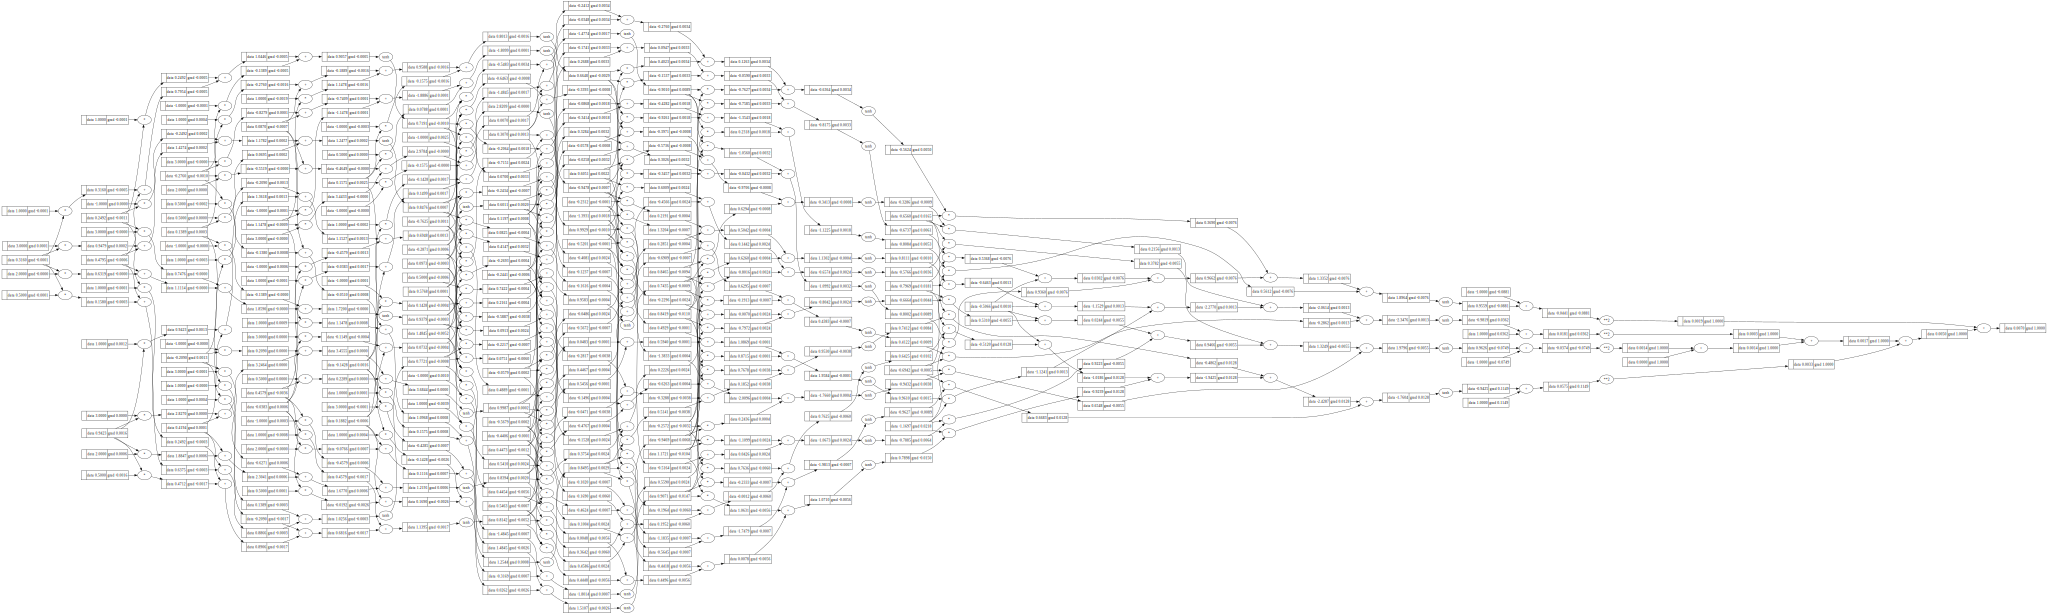

In [17]:
draw_dot(loss)